# Blind ROME Edit Detection — Demo

This notebook demonstrates the **PairedRatioDetector** — a blind method for
detecting which transformer layer was edited by ROME, without access to the
original base model.

## How it works
1. For each layer, compute ratio `σ_k(c_proj) / σ_k(c_fc)` for k ∈ {1,2,3}
2. Compute **local** z-scores (compare each layer to its neighbours)
3. Fuse z-scores via L2 norm → the edited layer stands out

In [10]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

ROOT = Path(".").resolve().parent
sys.path.insert(0, str(ROOT))

## 1. Load benchmark results

We load the latest **usable** benchmark run from `analysis_out/` (at least one non-skipped test with ratio scores).

In [11]:
# Find the latest usable results file
results_dir = ROOT / "analysis_out"
json_files = sorted(results_dir.glob("rome_structural_gpt2-large_*.json"))
if not json_files:
    raise FileNotFoundError(f"No benchmark files found in {results_dir}")

def _load_json(path: Path):
    with open(path) as f:
        return json.load(f)

def _usable_tests(run_data: dict):
    good = []
    for t in run_data.get("tests", []):
        if t.get("skipped"):
            continue
        rd = t.get("ratio_detection", {})
        if rd.get("per_layer_scores"):
            good.append(t)
    return good

results_file = None
data = None
tests = []

for candidate in reversed(json_files):
    run_data = _load_json(candidate)
    run_tests = _usable_tests(run_data)
    if run_tests:
        results_file = candidate
        data = run_data
        tests = run_tests
        break

if data is None:
    results_file = json_files[-1]
    data = _load_json(results_file)
    tests = _usable_tests(data)
    print("Warning: no usable run with successful ratio detections found; using latest file anyway.")

target_layer = data.get("metadata", {}).get("target_layer", 12)
print(f"Loading: {results_file.name}")
print(f"Model: {data.get('metadata', {}).get('model')}, Target layer: {target_layer}")
print(f"Usable tests: {len(tests)}, Summary: {data.get('summary', {})}")

Loading: rome_structural_gpt2-large_2026-02-23_16-25-43.json
Model: gpt2-large, Target layer: 12
Usable tests: 1, Summary: {'total_tests': 1, 'successful_tests': 1, 'skipped_tests': 0, 'rome_success_rate': 1.0, 'spectral_detection_accuracy': 0.0, 'ratio_detection_accuracy': 1.0}


## 2. Per-layer detection scores

The detection score is the L2 norm of the z-score vector at each layer.
We expect to see a clear peak at layer 12 (the ROME target).

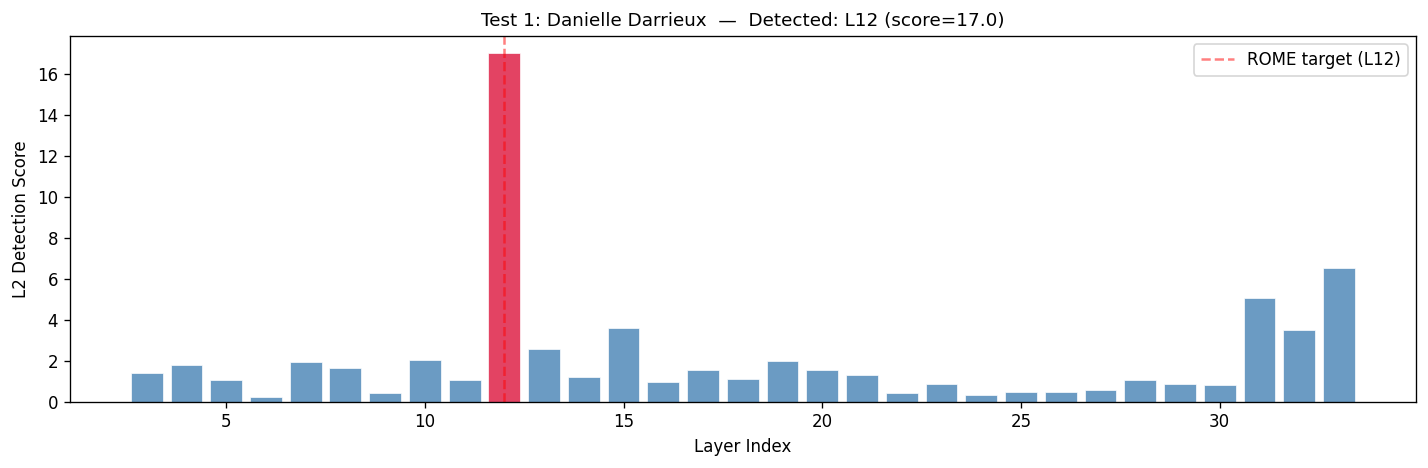

In [12]:
if not tests:
    print("No usable tests to plot. Run the benchmark again and ensure at least one non-skipped edit succeeds.")
else:
    fig, axes = plt.subplots(len(tests), 1, figsize=(12, 4*len(tests)), sharex=True)
    if len(tests) == 1:
        axes = [axes]

    for i, (ax, test) in enumerate(zip(axes, tests)):
        rd = test['ratio_detection']
        scores = rd['per_layer_scores']
        layers = sorted(scores.keys(), key=int)
        vals = [scores[l] for l in layers]
        layer_ints = [int(l) for l in layers]
        
        colors = ['crimson' if l == target_layer else 'steelblue' for l in layer_ints]
        ax.bar(layer_ints, vals, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
        ax.axvline(target_layer, color='red', linestyle='--', alpha=0.5, label=f'ROME target (L{target_layer})')
        
        detected = rd.get('anomalous_layer', rd.get('detected_layer'))
        if detected is not None:
            detected = int(detected) if not isinstance(detected, int) else detected
        
        ax.set_ylabel('L2 Detection Score')
        ax.set_title(f"Test {i+1}: {test['subject']}  —  Detected: L{detected} (score={rd['detection_score']:.1f})", fontsize=11)
        ax.legend()

    axes[-1].set_xlabel('Layer Index')
    plt.tight_layout()
    plt.show()

## 3. Per-feature z-scores breakdown

We can see which SV ratios contribute most to the detection.
Typically `sv_ratio_2` (σ₃) carries the strongest signal.

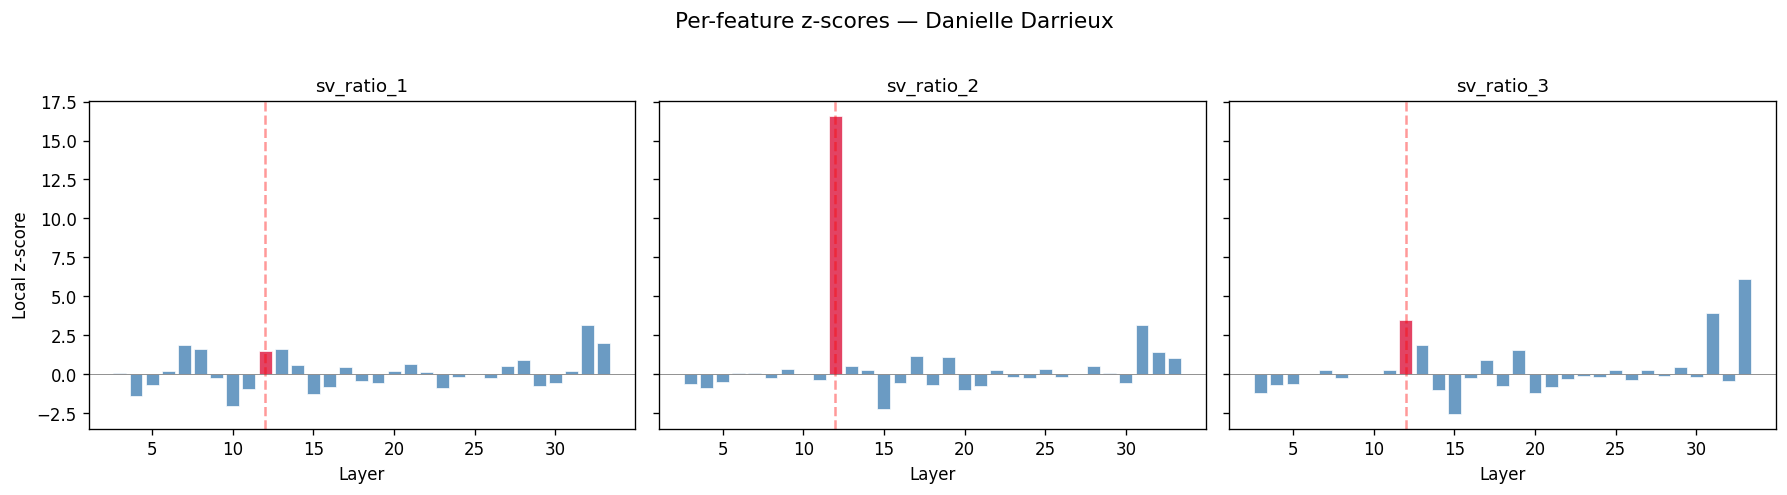

In [13]:
if not tests:
    print("No usable tests for per-feature breakdown.")
else:
    test = tests[0]
    rd = test.get('ratio_detection', {})
    per_feature = rd.get('per_feature_z', {})
    
    if not per_feature:
        print("No per_feature_z found in this run.")
    else:
        fig, axes = plt.subplots(1, len(per_feature), figsize=(5*len(per_feature), 4), sharey=True)
        if len(per_feature) == 1:
            axes = [axes]

        feature_names = sorted(per_feature.keys())
        for ax, feat in zip(axes, feature_names):
            zvals = per_feature[feat]
            layers = sorted(zvals.keys(), key=int)
            z_arr = [zvals[l] for l in layers]
            layer_ints = [int(l) for l in layers]
            
            colors = ['crimson' if l == target_layer else 'steelblue' for l in layer_ints]
            ax.bar(layer_ints, z_arr, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
            ax.axhline(0, color='gray', linewidth=0.5)
            ax.axvline(target_layer, color='red', linestyle='--', alpha=0.4)
            ax.set_title(feat, fontsize=11)
            ax.set_xlabel('Layer')

        axes[0].set_ylabel('Local z-score')
        fig.suptitle(f"Per-feature z-scores — {test['subject']}", fontsize=13, y=1.02)
        plt.tight_layout()
        plt.show()

## 4. Detector comparison table

In [14]:
if not tests:
    print("No usable tests for comparison table.")
else:
    has_spectral = any('spectral_detection' in t for t in tests)
    if has_spectral:
        print(f"{'Test':<5} {'Subject':<25} {'ROME':>5} {'Ratio':>10} {'Spectral':>10}")
        print("-" * 65)
    else:
        print(f"{'Test':<5} {'Subject':<25} {'ROME':>5} {'Ratio':>10}")
        print("-" * 52)

    def fmt(correct, det_layer):
        sym = '✅' if correct else '❌'
        return f"L{det_layer} {sym}"

    for i, t in enumerate(tests):
        acc = t.get('accuracy', {})
        ratio_det = t.get('ratio_detection', {}).get('anomalous_layer', t.get('ratio_detection', {}).get('detected_layer', '?'))
        rome_ok = '✅' if t.get('rome', {}).get('success') else '❌'

        if has_spectral:
            spectral_det = t.get('spectral_detection', {}).get('anomalous_layer', t.get('spectral_detection', {}).get('detected_layer', '?'))
            print(f"{i+1:<5} {t['subject']:<25} {rome_ok:>5} {fmt(acc.get('ratio_correct'), ratio_det):>10} {fmt(acc.get('spectral_correct'), spectral_det):>10}")
        else:
            print(f"{i+1:<5} {t['subject']:<25} {rome_ok:>5} {fmt(acc.get('ratio_correct'), ratio_det):>10}")

    s = data.get('summary', {})
    print(f"\n--- Summary ---")
    if 'ratio_detection_accuracy' in s:
        print(f"Ratio accuracy:    {s['ratio_detection_accuracy']:.0%}")
    if 'spectral_detection_accuracy' in s:
        print(f"Spectral accuracy: {s['spectral_detection_accuracy']:.0%}")

Test  Subject                    ROME      Ratio   Spectral
-----------------------------------------------------------------
1     Danielle Darrieux             ✅      L12 ✅      L30 ❌

--- Summary ---
Ratio accuracy:    100%
Spectral accuracy: 0%


## 5. Run live detection (optional)

This cell loads the model, applies a ROME edit, and runs the PairedRatioDetector live.
**Requires GPU and ~3GB VRAM.**

In [15]:
import torch
from omegaconf import OmegaConf
from src.handlers.rome import ModelHandler
from src.rome.common import gather_k, optimize_v, insert_kv
from src.structural.ratio_detector import PairedRatioDetector

cfg = OmegaConf.create({
    "model": {
        "handler": "gpt2", "name": "gpt2-large", "models_dir": str(ROOT / "models"),
        "second_moment_dir": str(ROOT / "second_moment_stats"),
        "device": "cuda" if torch.cuda.is_available() else "cpu",
        "save_to_local": True, "layer_name_template": "transformer.h.{}.mlp.c_proj",
        "layer": 12, "epochs": 25, "lr": 0.5, "kl_factor": 0.0625, "weight_decay": 0.5,
    }
})
handler = ModelHandler(cfg)
print(f"Loaded {cfg.model.name} on {cfg.model.device}, {handler.num_of_layers} layers")

Loading weights:   8%|▊         | 34/436 [00:00<00:00, 1426.36it/s, Materializing param=transformer.h.2.mlp.c_fc.weight]   

Loading weights: 100%|██████████| 436/436 [00:00<00:00, 2493.00it/s, Materializing param=transformer.wte.weight]             


Loaded gpt2-large on cuda, 36 layers


In [16]:
# Extract baseline weights
proj_weights = {
    idx: handler._get_module(handler._layer_name_template.format(idx)).weight.detach().clone()
    for idx in range(handler.num_of_layers)
}
fc_template = handler._layer_name_template.replace("c_proj", "c_fc")
fc_weights = {
    idx: handler._get_module(fc_template.format(idx)).weight.detach().clone()
    for idx in range(handler.num_of_layers)
}

# Apply ROME edit
fact = ("{} plays the sport of", "LeBron James", " basketball", " soccer")
print(f"Editing: '{fact[0].format(fact[1])}' → '{fact[2].strip()}'")
k = gather_k(handler, fact_tuple=fact, N=50)
delta = optimize_v(handler, fact_tuple=fact, N_prompts=50, N_optim_steps=25)
new_W, _ = insert_kv(handler, k, delta)

# Build modified weight dict
modified = {idx: w.clone() for idx, w in proj_weights.items()}
modified[12] = new_W.detach()
print(f"Edit applied to layer 12, delta norm = {delta.norm():.4f}")

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


Editing: 'LeBron James plays the sport of' → 'basketball'
Edit applied to layer 12, delta norm = 55.3857


In [17]:
# Run blind detection
detector = PairedRatioDetector()  # trim_first=3, trim_last=2, sv_indices=[1,2,3]
result = detector.detect(modified, fc_weights)

print(f"Detected layer: {result['anomalous_layer']}")
print(f"Detection score: {result['detection_score']:.2f}")
print(f"SV indices used: {result['sv_indices_used']}")
print(f"\nTop-5 layers by score:")
ranked = sorted(result['per_layer_scores'].items(), key=lambda x: x[1], reverse=True)[:5]
for layer, score in ranked:
    marker = " ← ROME TARGET" if layer == 12 else ""
    print(f"  Layer {layer:>2}: {score:>6.2f}{marker}")

Detected layer: 12
Detection score: 10.99
SV indices used: [1, 2, 3]

Top-5 layers by score:
  Layer 12:  10.99 ← ROME TARGET
  Layer 33:   6.54
  Layer 31:   5.04
  Layer 15:   3.61
  Layer 32:   3.50


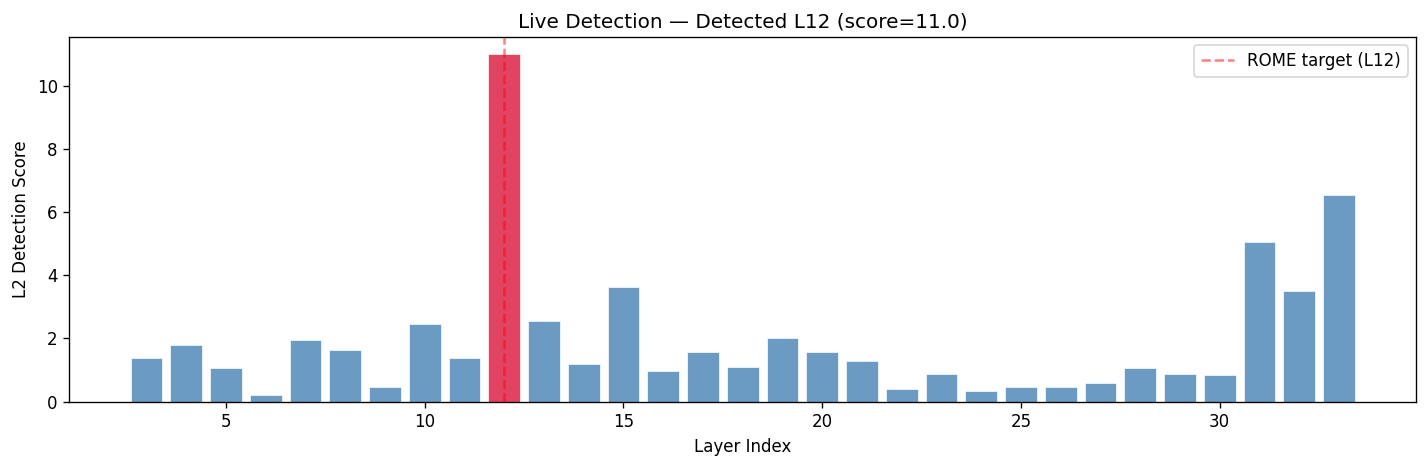

Model restored.


In [18]:
# Visualise live results
scores = result['per_layer_scores']
layers = sorted(scores.keys())
vals = [scores[l] for l in layers]
colors = ['crimson' if l == 12 else 'steelblue' for l in layers]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(layers, vals, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.axvline(12, color='red', linestyle='--', alpha=0.5, label='ROME target (L12)')
ax.set_xlabel('Layer Index')
ax.set_ylabel('L2 Detection Score')
ax.set_title(f'Live Detection — Detected L{result["anomalous_layer"]} (score={result["detection_score"]:.1f})')
ax.legend()
plt.tight_layout()
plt.show()

# Restore model
layer_name = handler._layer_name_template.format(12)
handler._get_module(layer_name).weight = torch.nn.Parameter(proj_weights[12])
print("Model restored.")

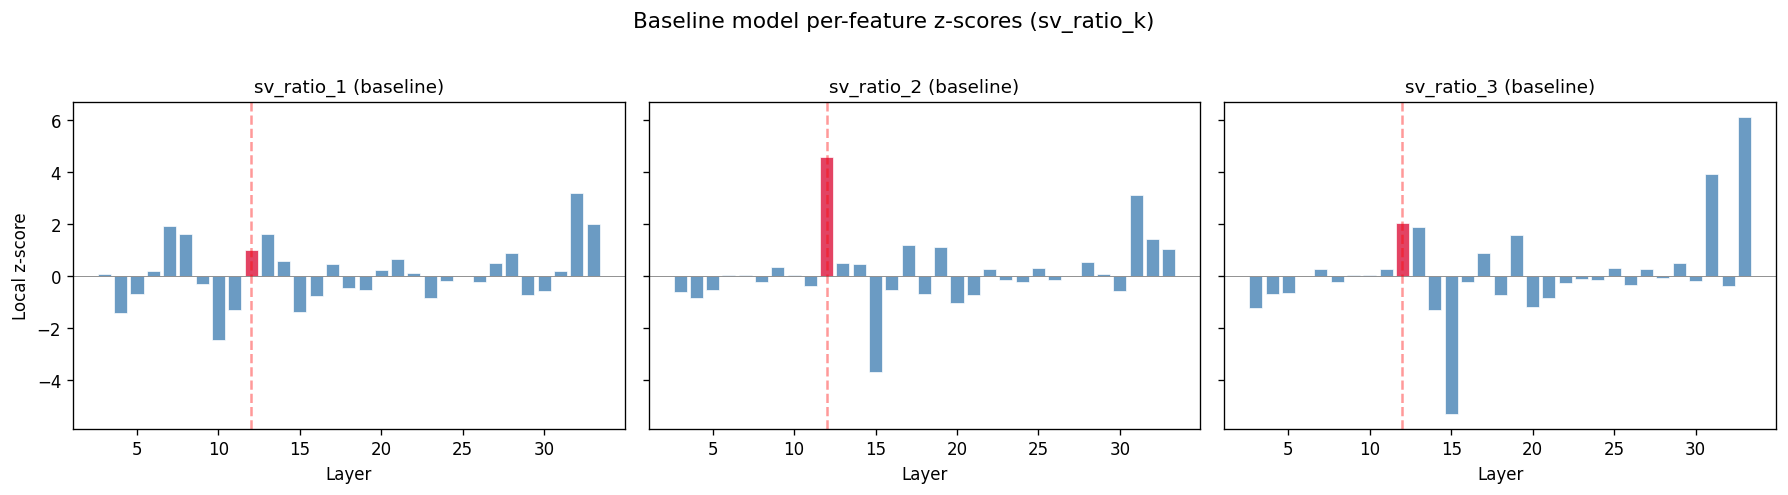

In [19]:
# Baseline model: per-feature z-scores (no edit)
# Source priority:
# 1) benchmark JSON baseline_ratio.per_feature_z
# 2) live recompute from baseline proj_weights/fc_weights if available
baseline_per_feature = None
baseline_eval_layers = None

base_block = data.get('baseline_ratio', {}) if isinstance(data, dict) else {}
if base_block.get('per_feature_z'):
    baseline_per_feature = base_block['per_feature_z']
    baseline_eval_layers = base_block.get('eval_layers')
elif 'proj_weights' in globals() and 'fc_weights' in globals():
    baseline_result = PairedRatioDetector().detect(proj_weights, fc_weights)
    baseline_per_feature = baseline_result.get('per_feature_z', {})
    baseline_eval_layers = baseline_result.get('eval_layers')

if not baseline_per_feature:
    print('No baseline per-feature z-scores available. Run benchmark with baseline_ratio output or run live baseline extraction cells first.')
else:
    feature_names = sorted(baseline_per_feature.keys())
    fig, axes = plt.subplots(1, len(feature_names), figsize=(5 * len(feature_names), 4), sharey=True)
    if len(feature_names) == 1:
        axes = [axes]

    for ax, feat in zip(axes, feature_names):
        zvals = baseline_per_feature[feat]
        layers = sorted(zvals.keys(), key=int)
        z_arr = [zvals[l] for l in layers]
        layer_ints = [int(l) for l in layers]

        colors = ['crimson' if l == target_layer else 'steelblue' for l in layer_ints]
        ax.bar(layer_ints, z_arr, color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
        ax.axhline(0, color='gray', linewidth=0.5)
        if target_layer is not None:
            ax.axvline(target_layer, color='red', linestyle='--', alpha=0.4)
        ax.set_title(f'{feat} (baseline)', fontsize=11)
        ax.set_xlabel('Layer')

    axes[0].set_ylabel('Local z-score')
    fig.suptitle('Baseline model per-feature z-scores (sv_ratio_k)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()